# FPC1500 als Network Analyzer (NA)

Dieses Notebook liest TRACE-Daten vom FPC1500 ein und stellt sie dar als:

- Amplitude linear über Frequenz
- Amplitude logarithmisch (dB) über Frequenz
- Smith-Chart

Ein Slider unter dem Smith-Chart wählt die Markerfrequenz. Der Marker wird in allen Plots eingezeichnet. Zusätzlich werden Reflexionsfaktor $\\Gamma$ und Impedanz $Z$ der Markerfrequenz angezeigt.

Am Ende wird ein Screenshot vom Gerät eingelesen und dargestellt.

In [ ]:
import json
import json
import socket
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from matplotlib.patches import Circle
from matplotlib.widgets import Slider

try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

# Verbindung / IO
FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 20.0
SCREENSHOT_TIMEOUT = 25.0
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024
SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

# VNA / Smith
Z0 = 50.0
SMITH_GRID_R = [0.0, 0.2, 0.5, 1.0, 2.0, 5.0]
SMITH_GRID_X = [0.2, 0.5, 1.0, 2.0, 5.0]

print(f"Konfiguration: {FPC_IP}:{FPC_PORT}")

Konfiguration: 192.168.1.10:5555


In [2]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    """SCPI Query: liest ASCII-Antwort bis Newline oder bis max_bytes.
    Unterstützt zusätzlich IEEE 488.2 Binary-Block, falls die Antwort als '#<d><len><payload>' kommt.
    """
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())

        buf = b""
        payload_decoded: str | None = None
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk

            # 1) ASCII-Antwort: endet häufig mit '\n'
            if b"\n" in buf:
                break

            # 2) IEEE Block: '#<d><len><payload>'
            hash_idx = buf.find(b"#")
            if hash_idx != -1 and len(buf) >= hash_idx + 2:
                d_char = buf[hash_idx + 1 : hash_idx + 2]
                if d_char and d_char.isdigit():
                    d = int(d_char.decode())
                    if len(buf) >= hash_idx + 2 + d:
                        try:
                            data_len = int(buf[hash_idx + 2 : hash_idx + 2 + d].decode())
                        except Exception:
                            data_len = None
                        if data_len is not None:
                            payload_start = hash_idx + 2 + d
                            payload_end = payload_start + data_len
                            if len(buf) >= payload_end:
                                payload = buf[payload_start:payload_end]
                                payload_decoded = payload.decode("utf-8", errors="replace").strip()
                                break

        if payload_decoded is not None:
            return payload_decoded
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def parse_float_list(raw: str) -> np.ndarray:
    vals = []
    for part in raw.replace(",", " ").split():
        try:
            vals.append(float(part))
        except ValueError:
            continue
    return np.asarray(vals, dtype=np.float64)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    try:
        f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
        f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    except Exception:
        cent = float(scpi_query(host, port, "FREQ:CENT?", max_bytes=256))
        span = float(scpi_query(host, port, "FREQ:SPAN?", max_bytes=256))
        f_start = cent - span / 2.0
        f_stop = cent + span / 2.0
    return np.linspace(f_start, f_stop, n)

def get_trace_gamma(host: str, port: int):
    """Versucht komplexe Reflexionsdaten (Gamma) zu lesen.

    Primär: komplexe Re/Im-Daten (SDAT). Sekundär: Betrag (TRACE1).

    Wenn nur Betrag verfügbar ist, wird Gamma mit Phase=0 angenommen.

    Returns: (freq_hz, gamma_complex, source_command, phase_assumed)
    """
    complex_cmds = [
        "CALC:DATA? SDAT",
        "CALC:DATA? SDAT,1",
        "CALC:DATA? SDAT,TRACE1",
        "TRAC:DATA? TRACE1,SDAT",
        "TRAC:DATA? TRACE1, SDAT",
    ]

    errors: list[str] = []
    for cmd in complex_cmds:
        try:
            raw = scpi_query(host, port, cmd, timeout=SOCKET_TIMEOUT, max_bytes=TRACE_READ_MAX_BYTES)
            arr = parse_float_list(raw)
            if arr.size < 4:
                errors.append(f"{cmd}: zu wenig Daten")
                continue

            # Tolerant: Falls ein einzelnes Residuum dabei ist, abschneiden.
            if arr.size % 2 == 1:
                arr = arr[:-1]

            if arr.size >= 4 and arr.size % 2 == 0:
                re = arr[0::2]
                im = arr[1::2]
                gamma = re + 1j * im
                freqs = get_freq_axis(host, port, gamma.size)
                return freqs, gamma.astype(np.complex128), cmd, False

            errors.append(f"{cmd}: keine interpretierbaren Re/Im-Paare (arr.size={arr.size})")
        except Exception as ex:
            errors.append(f"{cmd}: {ex}")

    # Fallback: nur Betrag (typisch TRAC:DATA? TRACE1)
    raw_mag = scpi_query(host, port, "TRAC:DATA? TRACE1", timeout=SOCKET_TIMEOUT, max_bytes=TRACE_READ_MAX_BYTES)
    mag_vals = parse_float_list(raw_mag)
    if mag_vals.size < 2:
        raise RuntimeError(
            "NA konnte weder komplex noch Betrag auslesen. "
            + " | ".join(errors)
            + " | Fallback TRAC:DATA? TRACE1 war leer."
        )

    freqs = get_freq_axis(host, port, mag_vals.size)

    # Heuristik: Viele FPC/SA-Traces sind bereits in dB.
    mag_min = float(np.nanmin(mag_vals))
    mag_max = float(np.nanmax(mag_vals))
    looks_like_db = mag_max <= 3.0 and mag_min < -0.5

    if looks_like_db:
        mag_db = mag_vals
        mag_lin = 10.0 ** (mag_db / 20.0)
    else:
        mag_lin = mag_vals
        mag_db = 20.0 * np.log10(np.maximum(mag_lin, 1e-12))

    # Smith braucht komplex. Wenn nur Betrag verfügbar ist, nehmen wir Phase=0 (gamma liegt auf positiver re-Achse).
    gamma_assumed = mag_lin.astype(np.complex128)
    src = "TRAC:DATA? TRACE1 (magnitude-only fallback; Phase=0 assumed)"
    return freqs, gamma_assumed, src, True

def gamma_to_impedance(gamma: np.ndarray, z0: float = Z0) -> np.ndarray:
    den = (1.0 - gamma)
    eps = 1e-12
    den = np.where(np.abs(den) < eps, den + eps, den)
    return z0 * (1.0 + gamma) / den

def screenshot_save(host: str, port: int, filename: str = "screen.png"):
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        return None
    except Exception as ex:
        return str(ex)
    finally:
        s.close()

def screenshot_read(host: str, port: int, filename: str):
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        while len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2:2 + n_digits].decode())
        payload = buf[2 + n_digits:]
        while len(payload) < data_len:
            chunk = s.recv(min(65536, data_len - len(payload)))
            if not chunk:
                break
            payload += chunk
        return payload[:data_len] if len(payload) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

In [ ]:
idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
print("Geraet:", idn if idn else "Keine Antwort")

freq_hz, gamma, src, phase_assumed = get_trace_gamma(FPC_IP, FPC_PORT)
z = gamma_to_impedance(gamma, Z0)
mag_lin = np.abs(gamma)
mag_db = 20.0 * np.log10(np.maximum(mag_lin, 1e-12))

print(f"Datenquelle: {src}")
print(f"Samples: {gamma.size}, f_start={freq_hz[0]/1e6:.3f} MHz, f_stop={freq_hz[-1]/1e6:.3f} MHz")

Geraet: Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90
Datenquelle: TRAC:DATA? TRACE1 (magnitude-only fallback; Phase=0 assumed)
Samples: 201, f_start=2.000 MHz, f_stop=200.000 MHz


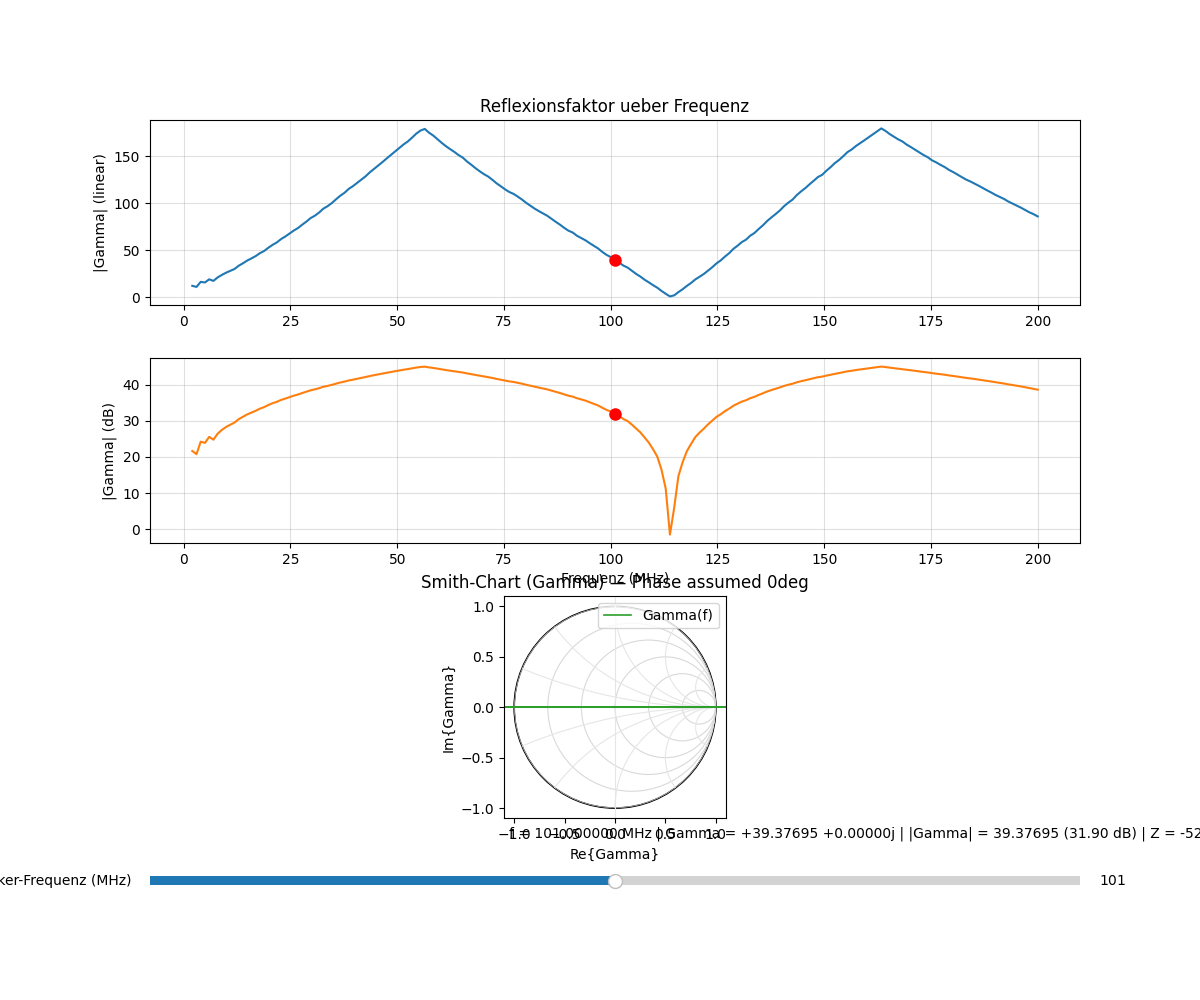

In [4]:
# Robustheit: Falls du dieses Plot-Cell isoliert ausführst, müssen TRACE-Daten schon geladen sein.
# Wenn nicht, holen wir sie hier nach.
if ("freq_hz" not in globals()) or ("gamma" not in globals()):
    freq_hz, gamma, src, phase_assumed = get_trace_gamma(FPC_IP, FPC_PORT)
    z = gamma_to_impedance(gamma, Z0)
    mag_lin = np.abs(gamma)
    mag_db = 20.0 * np.log10(np.maximum(mag_lin, 1e-12))

def draw_smith_grid(ax):
    unit = Circle((0, 0), 1.0, edgecolor="black", facecolor="none", lw=1.2)
    ax.add_patch(unit)
    ax.axhline(0.0, color="0.7", lw=0.8)
    ax.axvline(0.0, color="0.9", lw=0.8)

    # Konstante r-Kreise
    for r in SMITH_GRID_R:
        c = r / (1.0 + r)
        rad = 1.0 / (1.0 + r)
        circ = Circle((c, 0.0), rad, edgecolor="0.85", facecolor="none", lw=0.8)
        circ.set_clip_path(unit)
        ax.add_patch(circ)

    # Konstante x-Kreise
    for x in SMITH_GRID_X:
        for sx in (+1.0, -1.0):
            xx = sx * x
            circ = Circle((1.0, 1.0 / xx), 1.0 / abs(xx), edgecolor="0.9", facecolor="none", lw=0.8)
            circ.set_clip_path(unit)
            ax.add_patch(circ)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel("Re{Gamma}")
    ax.set_ylabel("Im{Gamma}")
    ax.set_title("Smith-Chart (Gamma)")
    ax.grid(False)

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(4, 1, height_ratios=[1.0, 1.0, 1.2, 0.10], hspace=0.35)

ax_lin = fig.add_subplot(gs[0, 0])
ax_db = fig.add_subplot(gs[1, 0], sharex=ax_lin)
ax_smith = fig.add_subplot(gs[2, 0])
ax_slider = fig.add_subplot(gs[3, 0])

f_mhz = freq_hz / 1e6
ax_lin.plot(f_mhz, mag_lin, color="C0", lw=1.5)
ax_lin.set_ylabel("|Gamma| (linear)")
ax_lin.set_title("Reflexionsfaktor ueber Frequenz")
ax_lin.grid(True, alpha=0.4)

ax_db.plot(f_mhz, mag_db, color="C1", lw=1.5)
ax_db.set_ylabel("|Gamma| (dB)")
ax_db.set_xlabel("Frequenz (MHz)")
ax_db.grid(True, alpha=0.4)

draw_smith_grid(ax_smith)
if "phase_assumed" in globals() and phase_assumed:
    ax_smith.set_title("Smith-Chart (Gamma) — Phase assumed 0deg")
ax_smith.plot(np.real(gamma), np.imag(gamma), color="C2", lw=1.2, label="Gamma(f)")
ax_smith.legend(loc="upper right")

idx0 = int(np.argmin(np.abs(f_mhz - np.mean(f_mhz))))
m_lin, = ax_lin.plot([f_mhz[idx0]], [mag_lin[idx0]], marker="o", color="red", ms=8)
m_db, = ax_db.plot([f_mhz[idx0]], [mag_db[idx0]], marker="o", color="red", ms=8)
m_smith, = ax_smith.plot([np.real(gamma[idx0])], [np.imag(gamma[idx0])], marker="o", color="red", ms=8)

info_text = ax_smith.text(
    -1.05,
    -1.18,
    "",
    fontsize=10,
    ha="left",
    va="top",
    transform=ax_smith.transData,
)

slider = Slider(
    ax=ax_slider,
    label="Marker-Frequenz (MHz)",
    valmin=float(f_mhz.min()),
    valmax=float(f_mhz.max()),
    valinit=float(f_mhz[idx0]),
)

def update_marker(f_sel_mhz):
    idx = int(np.argmin(np.abs(f_mhz - f_sel_mhz)))
    g = gamma[idx]
    zi = z[idx]

    m_lin.set_data([f_mhz[idx]], [mag_lin[idx]])
    m_db.set_data([f_mhz[idx]], [mag_db[idx]])
    m_smith.set_data([np.real(g)], [np.imag(g)])

    phase_note = " (Phase assumed 0deg)" if ("phase_assumed" in globals() and phase_assumed) else ""

    info_text.set_text(
        f"f = {f_mhz[idx]:.6f} MHz | Gamma = {np.real(g):+.5f} {np.imag(g):+.5f}j | "
        f"|Gamma| = {np.abs(g):.5f} ({20*np.log10(max(np.abs(g),1e-12)):.2f} dB) | "
        f"Z = {np.real(zi):.2f} {np.imag(zi):+.2f}j Ohm" + phase_note
    )
    fig.canvas.draw_idle()

slider.on_changed(update_marker)
update_marker(f_mhz[idx0])
plt.show()

Gespeichert: C:\_Git\KT-workspace\lab_suite\labs\03_03_LABOR-3\screenshots\fpc1500_20260323_105842.png


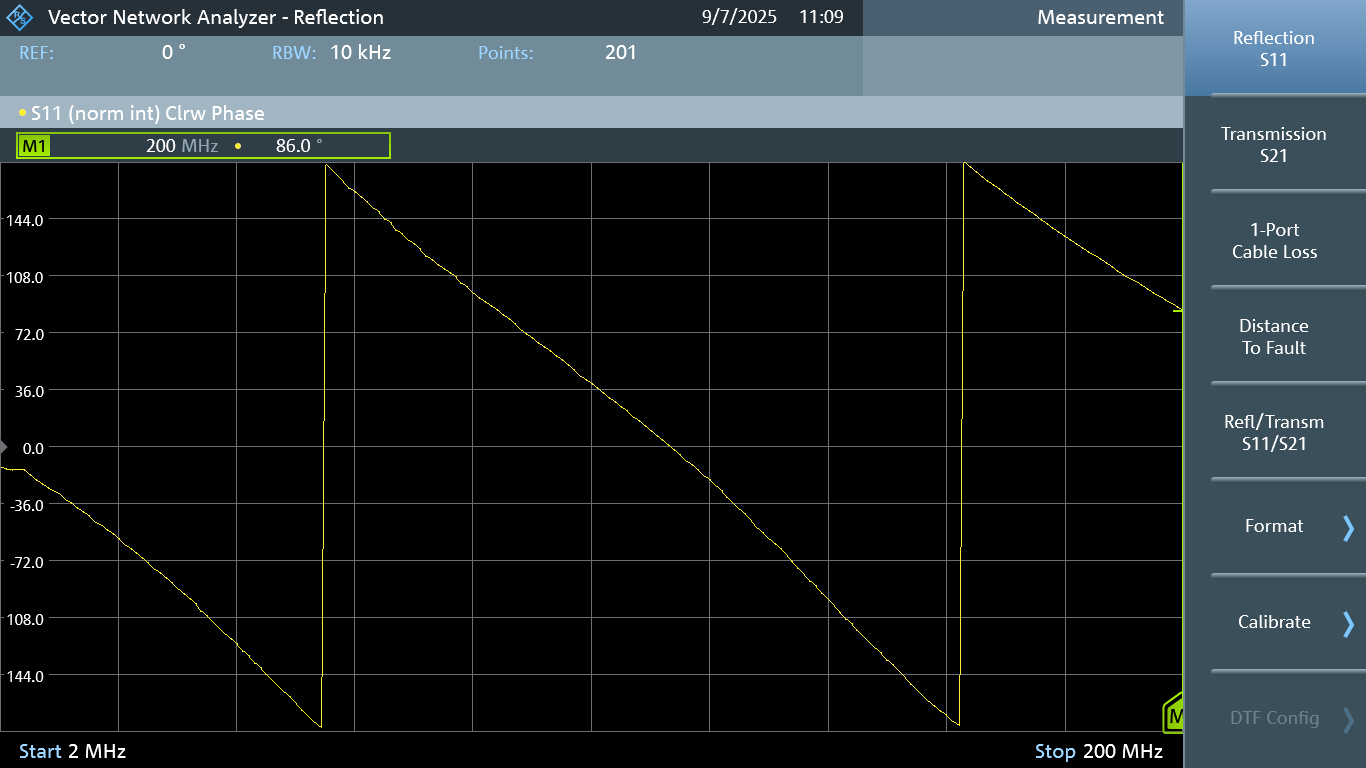

In [5]:
SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)
err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
if err:
    print("Screenshot speichern auf dem Geraet fehlgeschlagen:", err)
else:
    png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if png_bytes:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        out_path = SCREENSHOT_DIR / f"fpc1500_{timestamp}.png"
        out_path.write_bytes(png_bytes)
        print("Gespeichert:", out_path.resolve())
        display(Image(data=png_bytes))
    else:
        print("Screenshot konnte nicht gelesen werden.")

In [ ]:
# Diagnose: TRACE1..TRACE4 auslesen und Inhalt grob einordnen

def classify_trace_values(vals: np.ndarray) -> str:
    if vals.size == 0:
        return "leer"
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))

    # Grobe Heuristik, nur als Diagnose-Hinweis
    if vmin >= -220.0 and vmax <= 50.0 and (vmax - vmin) > 3.0:
        return "wirkt wie dB/Amplitude"
    if vmin >= -190.0 and vmax <= 190.0 and (vmax - vmin) > 30.0:
        return "koennte Phase (deg) sein"
    if vmin >= 0.0 and vmax <= 1.5:
        return "koennte |Gamma| linear sein"
    return "nicht eindeutig"


def safe_syst_err(host: str, port: int) -> str:
    try:
        return scpi_query(host, port, "SYST:ERR?", max_bytes=512)
    except Exception as ex:
        return f"SYST:ERR? fehlgeschlagen: {ex}"


for tr in range(1, 5):
    cmd = f"TRAC:DATA? TRACE{tr}"
    print("=" * 80)
    print(cmd)
    try:
        raw = scpi_query(FPC_IP, FPC_PORT, cmd, timeout=SOCKET_TIMEOUT, max_bytes=TRACE_READ_MAX_BYTES)
        arr = parse_float_list(raw)

        if arr.size == 0:
            print("Keine numerischen Werte empfangen.")
        else:
            vmin = float(np.nanmin(arr))
            vmax = float(np.nanmax(arr))
            hint = classify_trace_values(arr)
            preview = np.array2string(arr[:8], precision=4, separator=", ")
            print(f"N={arr.size}, min={vmin:.4f}, max={vmax:.4f}, Hinweis: {hint}")
            print(f"Erste Werte: {preview}")

            if arr.size % 2 == 0 and arr.size >= 4:
                re = arr[0::2]
                im = arr[1::2]
                g = re + 1j * im
                g_abs = np.abs(g)
                g_ang = np.degrees(np.angle(g))
                print(
                    "Re/Im-Test: gerade Anzahl -> als Paare interpretierbar, "
                    f"|g| in [{g_abs.min():.4f}, {g_abs.max():.4f}], "
                    f"phase in [{g_ang.min():.2f}, {g_ang.max():.2f}] deg"
                )
            else:
                print("Re/Im-Test: keine plausible Paarstruktur (ungerade N oder zu kurz).")

    except Exception as ex:
        print(f"Fehler bei {cmd}: {ex}")

    print("SYST:ERR? ->", safe_syst_err(FPC_IP, FPC_PORT))

print("=" * 80)
print("Hinweis: TRACE2 liefert nur dann Phase, wenn TRACE2 am Geraet explizit als Phasen-Trace konfiguriert ist.")